# LMECA2300: Advanced Numerical Methods
## Assignment 6

**Students:**
- Student 1: Victor Lepère (61502000)
- Student 2: Max Opdecam(77062000)

### Full multipole code

We will assess the efficiency of the multipole decomposition compared to the convolution method. To do so, we first begin by importing the necessary packages and defining some physical constants.

In [3]:
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
import matplotlib.animation as manim
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg') 
from scipy.special import hankel2

### Physical constants
rho0 = 1.2 # air, 20°C, 1 atm
f = 1000 # [hz]
w = 2*np.pi*f # air -> 343 = w/k
k = w/343
lambda_ = (2*np.pi)/k

We define below the `Segment` class which features convolution-based implementation of the radiation integral.

In [5]:
class Segment:

    def __init__(self, r1, r2):
        self.r1 = np.asarray(r1)
        self.r2 = np.asarray(r2)
        self.Vn = 1

    def set_Vn(self, Vn):
        self.Vn = Vn

    def __str__(self):
        return f"({self.r1[0]:.2f}, {self.r1[1]:.2f}) ---- ({self.r2[0]:.2f}, {self.r2[1]:.2f})"

    def length(self):
        return np.linalg.norm(self.r2 - self.r1)

    def F(self, u_beta):
        p_half = k*(u_beta@(self.r2 - self.r1))/2
        return np.exp(1j*k*u_beta@self.r1) * self.length() * np.exp(1j*p_half) * np.sinc(p_half / np.pi)
    
    def sym_radiated_field(self, mid, m=40):
        """
        Integrates complex amplitude for an obsever point ON the segment (MIDPOINT), and thus takes advantage of symmetry.

        @param mid: coord. of midpoint
        """        
        s = np.linspace(0, 1, m)
        diff = s[:, np.newaxis] * (self.r2 - mid)
        rho = np.linalg.norm(diff, axis=1)
        singularity_mask = k*rho <= lambda_/1000

        evals = np.zeros_like(rho, dtype=np.complex128)
        j2pi = 1j*(2/np.pi)
        cst = 1 - j2pi*(np.euler_gamma - np.log(2))
        evals[singularity_mask] = cst
        subset_rho = rho[~singularity_mask]
        evals[~singularity_mask] = hankel2(0, k*subset_rho) + j2pi*np.log(k*subset_rho)
        evals[0] *= .5; evals[-1] *= .5
        
        first_term = np.sum(evals)/m
        second_term = -j2pi * (np.log(k) + np.log(self.length()) - np.log(2) - 1)

        return self.Vn * w * rho0 * self.length() * (first_term + second_term) / 4.
    
    def conv_radiated_field(self, grid_domain, m=2000):
        """
        Radiation integral computation from HW2 using convolution
        """
        grid_domain = np.atleast_2d(grid_domain) # (N,2)

        s = np.linspace(0, 1, m) # (m,)
        diff = grid_domain[:, np.newaxis, :] - (self.r1 + s[:, np.newaxis] * (self.r2-self.r1)) # (N,m,2)
        rho = np.linalg.norm(diff, axis=-1) # (N,m)

        H = hankel2(0, k * rho) # (N,m)
        if np.any(np.isnan(H)):
            raise ValueError("Hankel function evaluated at singular point, change geometry or grid.")
        
        H[:, 0] *= 1/2
        H[:, -1] *= 1/2

        integral = self.Vn * w * rho0 * self.length() * np.sum(H, axis=1) / (4*m) # (N,)
        return integral

We now present the geometry that will be used to evaluate the methods. Our implementation relies on inheritance. The grids of boxes representing the source and observation domains in the multipole code are abstracted under the `Boxes`class. Then this base class is extended for the source and obs. cases to feature additional methods, returning the radiation patterns of the enclosed segments and the translation function associated to the observation box, respectively. As scattering objects, we distribute randomly some polygons in each box of the source domain whose sides length $\frac{\lambda}{10}$ and number of boundary segments range from $3$ to $5$.

In the example geometry, the source domain is made of 16 boxes of side length $\frac{\lambda}{6}$ while the obs. domain is composed of 9 boxes with size $\lambda$. Furthermore, we consider 100 nodes for each box where to compute pressure field.

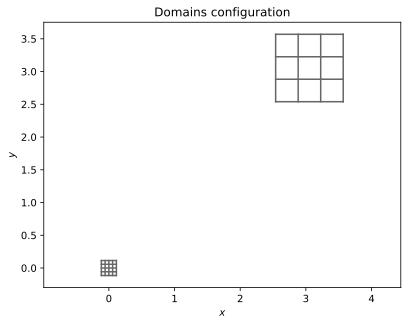

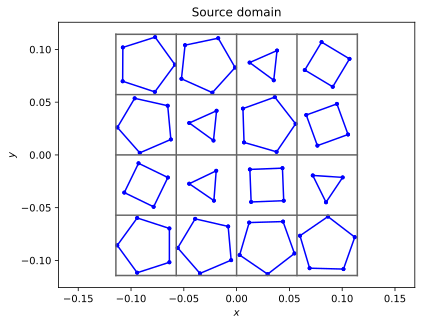

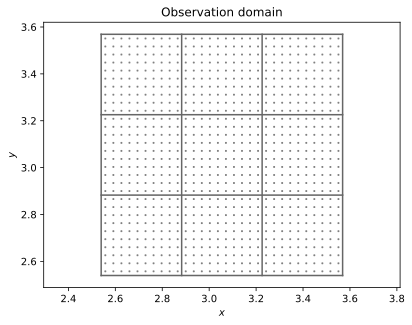

In [7]:
# another geometry
def generate_circle(center, radius, length=lambda_/10, pitch=0):
    """
    Parameters
    ----------
    rayon : int
        rayon en cellule.
    center : (int,int)
        index matrice du centre.
    Returns
    -------
    liste des edges du pourtour de la section.
    """
    
    circonf = 2*np.pi*radius
    n_edges = int(np.ceil(circonf/length))
    
    angle = 360/n_edges/180*np.pi
    r1 = np.array(center) + np.array((radius*np.cos(pitch), radius*np.sin(pitch)))
    all_edges = []
    current_angle = angle + pitch
    
    #création des edges
    for _ in range(n_edges):
        r2 = center + np.array((radius*np.cos(current_angle), radius*np.sin(current_angle)))
        edge = Segment(r1, r2)
        all_edges.append(edge)
        r1 = r2
        current_angle = current_angle + angle

    return all_edges

class Boxes:
    """
    Grid of boxes
    """
    def __init__(self, center, gridsize, n_boxes):
        """
        @param center: center of grid in global coordinates
        @param gridsize: length of side's square boxes
        @param n_boxes: number of boxes along each dimension
        """
        self.center = np.asarray(center)
        self.gridsize = gridsize
        self.n_boxes = n_boxes

        self.__create_axes()

    def __create_axes(self):
        """
        Creates list of origin coordinates corresponding to each local axes of boxes
        """
        self.axes = []
        self.__bottom_left = self.center - (self.n_boxes/2.) * self.gridsize
        for i in range(self.n_boxes):
            for j in range(self.n_boxes):
                self.axes.append(
                    self.__bottom_left + np.ones(2) * (self.gridsize/2.) + np.array([i*self.gridsize, j*self.gridsize])
                )
    
    def get_origin(self, i, j):
        return self.axes[(self.n_boxes-1-i) + j*self.n_boxes]

    def plot(self):
        for i in range(self.n_boxes+1):
            plt.plot(
                [self.__bottom_left[0], self.__bottom_left[0] + self.n_boxes*self.gridsize],
                [self.__bottom_left[1]+i*self.gridsize] * 2,
                color = "0.4"
            )
            plt.plot(
                [self.__bottom_left[0]+i*self.gridsize] * 2,
                [self.__bottom_left[1], self.__bottom_left[1] + self.n_boxes*self.gridsize],
                color = "0.4"
           )
            
class SourceDomain(Boxes):
    def __init__(self, center, gridsize, n_boxes):
        super().__init__(center, gridsize, n_boxes)

    def get_F(self, i, j, shape):
        """
        Returns radiation patterns from box (i, j) containing segments of shape
        """
        def F(beta):
            itg = 0.
            u_beta = np.array([np.cos(beta), np.sin(beta)])
            local_origin = self.get_origin(i,j)
            for s in shape:
                r2 = s.r2 - local_origin
                r1 = s.r1 - local_origin

                p_half = k*(u_beta@(r2 - r1))/2
                itg += s.Vn * np.exp(1j*k*u_beta@r1) * s.length() * np.exp(1j*p_half) * np.sinc(p_half / np.pi)
            return itg
        return F
        
class ObsDomain(Boxes):
    def __init__(self, center, gridsize, n_boxes):
        super().__init__(center, gridsize, n_boxes)

    def get_T(self, i, j, source_origin):
        """
        Returns translation function between source and box (i, j) of observation grid
        """
        def T(beta, L=30):
            local_origin = self.get_origin(i, j)
            R0 = local_origin - source_origin
            phi0 = np.arctan2(R0[1], R0[0]) % (2 * np.pi) # the angles ranges from 0 to 2pi, as for beta rather than -pi, pi 

            l_values = np.arange(L + 1)
            c_values = np.where(l_values > 0, 2 * (-1j) ** l_values, 1)
            assert c_values[0] == 1
            H2_values = hankel2(l_values, k*np.linalg.norm(R0))
            result = c_values * np.cos(l_values * (beta - phi0)) * H2_values
        
            return np.sum(result)
        return T

def generate_mesh(domain, points_per_box):
    """
    Generates a mesh centered on the observation domain with points_per_box along each dimensions in each box.
    ! Assumes center of obs domain has positive coordinates !
    """
    shift = (domain.n_boxes/2.) * domain.gridsize
    left = domain.center[0] - shift
    right = domain.center[1] + shift

    m = points_per_box * domain.n_boxes
    offset = (right - left) / (2*(m-1))
    x = np.linspace(left+offset, right-offset, m)
    X, Y = np.meshgrid(x,x[::-1])

    return np.column_stack((X.ravel(), Y.ravel()))

src_by_side = 4
obs_by_side = 3

### source domain
source_domain = SourceDomain([0, 0], lambda_/6, src_by_side)

### observation domain
obs_domain = ObsDomain([(source_domain.n_boxes/2) * source_domain.gridsize + np.sqrt(2)*5*lambda_ + (obs_by_side/2)*lambda_]*2, lambda_, obs_by_side)

### shapes
groups = []
for i in range(src_by_side):
    row = []
    for j in range(src_by_side):
        source_domain.get_origin(i, j)
        n_edges = np.random.randint(3, 6)
        pitch_angle = np.random.uniform(0, np.pi/2)
        row.append(
            generate_circle(source_domain.get_origin(i, j), n_edges*lambda_/(20*np.pi), pitch=pitch_angle)
        )
    groups.append(row)

### show geometry
plt.cla()
plt.title("Domains configuration")
source_domain.plot()
obs_domain.plot()
plt.axis("equal")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.show()

plt.title("Source domain")
for row in groups:
    for g in row:
        for s in g:
            plt.plot([s.r1[0], s.r2[0]], [s.r1[1], s.r2[1]], "b.-")
source_domain.plot()
plt.axis("equal")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.show()

plt.title("Observation domain")
obs_domain.plot()
mesh_points = 10
mesh = generate_mesh(obs_domain, mesh_points)
plt.scatter(mesh[:, 0], mesh[:, 1], c='gray', marker='s', s=0.75)
plt.axis("equal")
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.show()

The first step consists of computing the normal velocity distribution over the shapes' boundaries. To do so, we consider an excitation field with direction $\hat{\bold u} = -\frac{\sqrt{2}}{2} (1, 1)$ and apply the techniques from HW4, i.e. build a linear system s.t. the total pressure at each segment is zero. To verify the solution, we consider one of the polygon and verify that the total field inside it indeed sums up to 0.

[0.00216523+0.01810668j]


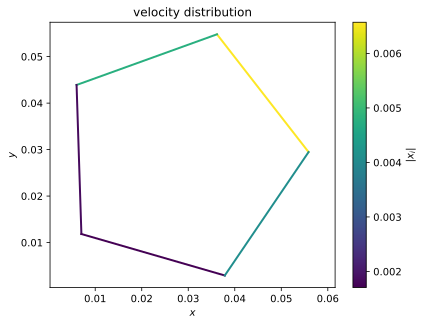

In [9]:
def build_system(shape, p_inc):
    """
    build linear system Ax = b as described above

    @param shape: a collection of Edge's
    @param p_inc: function that yields the complex amplitude of the incident field
    """
    N = len(shape)
    A = np.zeros((N, N), dtype=complex)
    b = np.zeros(N, dtype=complex)

    for i in range(N):
        edge = shape[i]
        midpoint = 0.5 * (edge.r1 + edge.r2)
        for j in range(N):
            edge = shape[j]
            if i == j:
                A[i,j] = edge.sym_radiated_field(midpoint)
            else:
                A[i,j] = edge.conv_radiated_field(midpoint, m=100)[0]
        b[i] = -p_inc(midpoint)

    return A,b 

### incident field    
P0 = 1
u_dir = [np.sqrt(2)/2, np.sqrt(2)/2]
p_inc = lambda r : P0 * np.exp(1j * k * (np.asarray(r) @ np.asarray(u_dir)))

### compute normal velocities for each shape
for _ in groups:
    for shape in _:
        A, b = build_system(shape, p_inc)
        xi = np.linalg.solve(A,b)

        # set solution for each segment
        for i in range(len(xi)):
            shape[i].set_Vn(xi[i])

shape = groups[1][2]
rad_field = 0.0
obs = source_domain.get_origin(1, 2)

for s in shape: rad_field += s.conv_radiated_field(source_domain.get_origin(1, 2), m=50)
tot = rad_field + p_inc(obs)
print(tot)


xi_abs = np.abs([s.Vn for s in shape])
norm = mcolors.Normalize(vmin=np.min(xi_abs), vmax=np.max(xi_abs))  
cmap = cm.viridis  # Choose a colormap

### Plot
plt.figure(dpi=150)
for i in range(len(shape)):
    color = cmap(norm(xi_abs[i]))  
    plt.plot([shape[i].r1[0], shape[i].r2[0]], [shape[i].r1[1], shape[i].r2[1]], "-", color=color, linewidth=2)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, label=r"$|x_i|$",ax=plt.gca())
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.axis('equal')
plt.title("velocity distribution")
plt.show()

In [10]:

gridsize = 100
x = np.linspace(-0.09, 0.15, gridsize)
X, Y = np.meshgrid(x, x)
coord_array = np.column_stack((X.ravel(), Y.ravel()))

# Radiated field computation
grid_radiated = np.zeros((gridsize * gridsize, len(shape)), dtype=complex)
for i in range(len(shape)):
    grid_radiated[:, i] = shape[i].conv_radiated_field(coord_array, m=100)

grid_radiated = np.sum(grid_radiated, axis=-1)
grid_incident = p_inc(coord_array)
grid_total = grid_radiated + grid_incident

# Plotting setup
plt.ioff()
fig, ax = plt.subplots()
delta_t = (1/f)/10

# Set color scale limits
vmax = np.max(np.real(grid_total))
vmin = np.min(np.real(grid_total))

# Initial pressure field reshaped for plotting
Z = np.real(grid_total).reshape(X.shape)

# Create the pcolormesh plot
quad = ax.pcolormesh(X, Y, Z, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
fig.colorbar(quad, ax=ax, label='Total pressure')

plt.rcParams["animation.html"] = "jshtml"
plt.ioff()
# Animation function
def animate2(frame):
    t = frame * delta_t
    pressures = np.real(grid_total * np.exp(1j * w * t)).reshape(X.shape)
    quad.set_array(pressures.ravel())
    return (quad,)

# Create the animation
manim.FuncAnimation(fig, animate2, frames=30, interval=120, blit=True)

 We use here the Full Multipole Decomposition to calculated the readited field far from our souces for each of our observations domaines. We paied attention to not recalculated our 'F($\beta$)' when it wasn't necesserary.

In [12]:

mesh_2d = mesh.reshape((mesh_points*obs_domain.n_boxes, mesh_points*obs_domain.n_boxes, 2))
mesh_radiated = np.zeros((mesh_2d.shape[0], mesh_2d.shape[1]), dtype=complex)

m = 300
betas = (2*np.pi/m) * np.arange(m + 1)
u_betas = np.hstack([np.cos(betas)[:, np.newaxis], np.sin(betas)[:, np.newaxis]])

# incidient field
mesh_inc = p_inc(mesh)

Fs = np.zeros((source_domain.n_boxes, source_domain.n_boxes, m + 1), dtype=complex)
for u in range(source_domain.n_boxes):
    for v in range(source_domain.n_boxes):
        F = source_domain.get_F(u, v, groups[u][v])
        Fs[u,v] = np.array([F(beta) for beta in betas])

for i in range(obs_domain.n_boxes):
    for j in range(obs_domain.n_boxes):
        obs_origin = obs_domain.get_origin(i, j)

        start_row = i*mesh_points
        end_row = start_row + mesh_points
        start_col = j*mesh_points
        end_col = start_col + mesh_points
        submesh = mesh_2d[start_row:end_row, start_col:end_col]
        submesh = submesh.reshape((-1, 2))

        #print((i,j))
        #print(obs_origin)
   
        exp = np.exp(-1j * k * np.einsum('md,nd->mn', submesh - obs_origin[np.newaxis, :], u_betas))

        for u in range(source_domain.n_boxes):
            for v in range(source_domain.n_boxes):
                source_origin = source_domain.get_origin(u, v)

                T = obs_domain.get_T(i, j, source_origin)
                Ts = np.array([T(beta, L=35) for beta in betas])

                evals = Ts[np.newaxis, :] * Fs[u, v][np.newaxis, :] * exp
                evals[:,0] *= .5; evals[:,-1] *= .5

                mesh_radiated[start_row:end_row, start_col:end_col] += (w*rho0 / (4*m)) * np.sum(evals, axis=1).reshape((mesh_points, mesh_points))

We then animate the result of our computations for the Full Multipole Decomposition.

In [14]:
plt.rcParams["animation.html"] = "jshtml"
plt.ioff()

# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
fig, ax = plt.subplots()

total_field = mesh_radiated.flatten() #

x = mesh[:, 0]
y = mesh[:, 1]

N = mesh_points * obs_domain.n_boxes

# Reshape into 2D grid
X = x.reshape((N, N))
Y = y.reshape((N, N))

dt = 1/(100*f)
# def animate(t):
#     plt.cla()
#     p = np.real(total_field * np.exp(1j* w * t * dt))
#     ax.plot_surface(X, Y, p.reshape(X.shape), alpha=.8)

#     #ax.view_init(elev=60, azim=20)
#     ax.set_zlim(-5, 5)
#     ax.set_title("total pressure field")
#     fig.tight_layout()
    

# manim.FuncAnimation(fig, animate, frames=50, interval=100)

vmin = np.min(np.real(total_field))
vmax = np.max(np.real(total_field))

quad = ax.pcolormesh(X, Y, np.zeros_like(Y), shading='auto', cmap='turbo', vmin=vmin, vmax=vmax)
fig.colorbar(quad, ax=ax, label='Total pressure')

# Animation function
def animate2(frame):
    t = frame * delta_t
    pressures = np.real(total_field * np.exp(1j * w * t)).reshape(X.shape)
    quad.set_array(pressures.ravel())
    return (quad,)

# Create the animation
manim.FuncAnimation(fig, animate2, frames=30, interval=120, blit=True)

Here we put back all the value of our readited mech to 0 and recalculate it like we did in HW2.

In [16]:
# with convolution
mesh_radiated = mesh_radiated.reshape((-1,))
mesh_radiated[:] = 0

for _ in groups:
    for shape in _:
        for s in shape:
            mesh_radiated += s.conv_radiated_field(mesh, m=1000)

We aniamte the result afterward and observe that the result look very similar to the Full Multipole Decomposition.

In [18]:
plt.ioff()

# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
fig, ax = plt.subplots()

total_field_cv = mesh_radiated.reshape((-1,)) #

x = mesh[:, 0]
y = mesh[:, 1]

N = mesh_points * obs_domain.n_boxes

# Reshape into 2D grid
X = x.reshape((N, N))
Y = y.reshape((N, N))

dt = 1/(100*f)
# def animate(t):
#     plt.cla()
#     p = np.real(total_field * np.exp(1j* w * t * dt))
#     ax.plot_surface(X, Y, p.reshape(X.shape), alpha=.8)

#     #ax.view_init(elev=60, azim=20)
#     ax.set_zlim(-5, 5)
#     ax.set_title("total pressure field")
#     fig.tight_layout()
    

# manim.FuncAnimation(fig, animate, frames=50, interval=100)

vmin = np.min(np.real(total_field_cv))
vmax = np.max(np.real(total_field_cv))

quad = ax.pcolormesh(X, Y, np.zeros_like(Y), shading='auto', cmap='turbo', vmin=vmin, vmax=vmax)
fig.colorbar(quad, ax=ax, label='Total pressure')

# Animation function
def animate2(frame):
    t = frame * delta_t
    pressures = np.real(total_field_cv * np.exp(1j * w * t)).reshape(X.shape)
    quad.set_array(pressures.ravel())
    return (quad,)

# Create the animation
manim.FuncAnimation(fig, animate2, frames=30, interval=120, blit=True)

To verify the differences between the two methodes we simply subtract one another and obtain a error of $10^{-5}$.

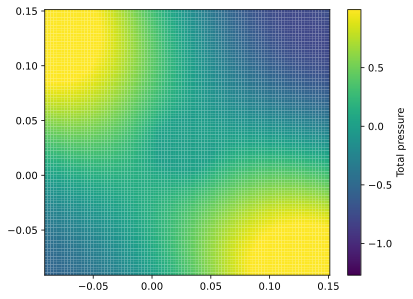

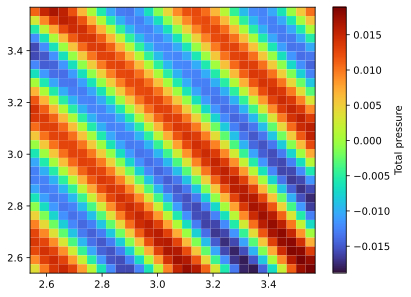

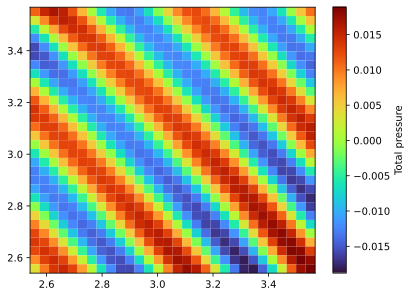

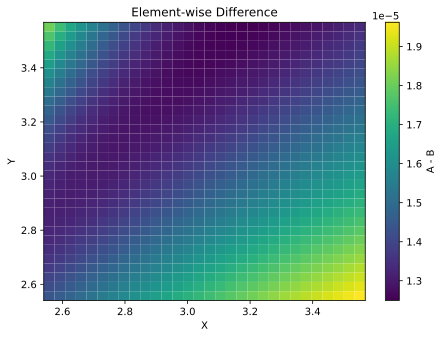

In [20]:

diff = np.abs(total_field - total_field_cv)  # Element-wise difference
diff = diff.reshape((obs_domain.n_boxes * mesh_points, obs_domain.n_boxes * mesh_points))
#print(diff)
fig, ax = plt.subplots()
quad = ax.pcolormesh(X, Y, diff, shading='auto', cmap='viridis', vmin=np.min(diff), vmax=np.max(diff))
fig.colorbar(quad, label="A - B")
ax.set_title("Element-wise Difference")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.tight_layout()
plt.show()
